This notebook serves a comparison purpose between few controll variables for future steps. The required setup is:

1. `density=0.25`
2. `shots=1000`
3. `seed=123` (following the previous IBM Fez experiment.)
4. `lengths = [2]+[4,10,20,50]`
5. Compare between `'edge_grab'`, `'matching'` and `'new'`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.transpiler import Target, CouplingMap
from qiskit.quantum_info import Operator
from qiskit.circuit.library import CXGate  # <-- Add this import
from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, QuantumAwesomeness
import os, random

# Fix random seed for numpy
SEED = 123 # pick your favorite int
os.environ["PYTHONHASHSEED"] = str(SEED)  # optional, for hash-based determinism
random.seed(SEED)
np.random.seed(SEED)

In [2]:
# Define parameters for the simulated backend
num_qubits = 16
basis_gates = ["id", "h", "x", "y", "z", "rz", "cx"]
p2 = 1e-2 # 2-qubit gate error probability
p1 = p2/10  # 1-qubit gate error probability
rz_angle = np.pi / 2  # Match initial_entangling_angle

shots = 1000 # 10000
lengths = [2]+[4,10,20,50] # ,100
num_samples = 20
 
cmap = CouplingMap.from_grid(4, 4, bidirectional=True)

In [3]:
# Create a Target object to define the gates, including rz explicitly
target = Target.from_configuration(
    num_qubits=num_qubits,
    basis_gates=basis_gates,
    coupling_map=cmap,
    custom_name_mapping={
        "id": Operator(np.array([[1, 0], [0, 1]])),  # Identity gate
        "h": Operator(np.array([[1, 1], [1, -1]]) / np.sqrt(2)),  # Hadamard gate
        "x": Operator(np.array([[0, 1], [1, 0]])),  # Pauli X gate
        "y": Operator(np.array([[0, -1j], [1j, 0]])),  # Pauli Y gate
        "z": Operator(np.array([[1, 0], [0, -1]])),  # Pauli Z gate
        "rz": Operator(
            [
                [np.cos(rz_angle / 2), -1j * np.sin(rz_angle / 2)],
                [-1j * np.sin(rz_angle / 2), np.cos(rz_angle / 2)],
            ]
        ),  # RZ(π/2)
        "cx": Operator(
            np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])
        ),  # CNOT gate
    },
)

# Create a noise model to emulate the NoisyBackend
noise_model = NoiseModel()

# Add depolarizing errors for 1-qubit and 2-qubit gates
error_1q = depolarizing_error(p1, 1)
error_2q = depolarizing_error(p2, 2)

# Apply errors to all basis gates except 'delay' and 'reset'
for gate in basis_gates:
    if gate in ["id", "h", "x", "y", "z", "rz"]:
        noise_model.add_all_qubit_quantum_error(error_1q, gate)
    elif gate == "cx":
        noise_model.add_all_qubit_quantum_error(error_2q, gate)

In [4]:
# Set up the AerSimulator with stabilizer method, target, and noise model
backend = AerSimulator(
    method="stabilizer",
    noise_model=noise_model if (p1 > 0 or p2 > 0) else None,
    target=target,
    max_parallel_threads=0,
    max_parallel_experiments=0,
    seed_simulator=SEED
)

In [5]:
# Test out the odd-even pattern sampler (different method of building, compared to NewSampler!)
exp = MirrorQA(
    range(num_qubits),
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=0.5,
    num_samples=num_samples,
    initial_entangling_angle=np.pi / 2,
    sampling_algorithm="new",  # 'edge_grab', 'matching', 'new', 'chess'
    seed=SEED,
    # full_sampling=True
)

# Set run options
exp.set_run_options(shots=shots)

rb_data = exp.run()
print(rb_data.job_ids)

# Print all available rounds, not a fixed range => WAIT
'''
for i in range(len(exp._pairs)):
    # Actually, it's not from 'rounds', so we changed the comments here
    print(f"Pairs in outermost layer for circuit with {lengths[i%len(lengths)]} rounds", exp._pairs[i])
'''

num_lengths = len(lengths)  # 5                                                                                                                                
                                             
for i in range(len(exp._pairs)):
    length = lengths[i % num_lengths]          # which sequence length
    sample = i // num_lengths                  # which repetition (0–19)                                                                                       
    print(f"Circuit {i:3d} | length={length:3d}, sample={sample:2d}: {exp._pairs[i]}")

['321472b2-28dc-47ed-857a-159ffba80157']
Circuit   0 | length=  2, sample= 0: [(4, 0), (10, 11), (5, 1), (13, 9), (7, 6), (8, 12), (3, 2), (14, 15)]
Circuit   1 | length=  4, sample= 0: [(4, 0), (10, 11), (5, 1), (13, 9), (7, 6), (8, 12), (3, 2), (14, 15)]
Circuit   2 | length= 10, sample= 0: [(13, 14), (15, 11), (4, 0), (1, 2), (7, 3), (6, 10), (8, 12), (5, 9)]
Circuit   3 | length= 20, sample= 0: [(0, 1), (13, 14), (6, 2), (9, 10), (3, 7), (5, 4), (11, 15), (8, 12)]
Circuit   4 | length= 50, sample= 0: [(10, 11), (15, 14), (3, 7), (12, 13), (9, 5), (2, 6), (4, 8), (1, 0)]
Circuit   5 | length=  2, sample= 1: [(0, 4), (1, 5), (10, 14), (12, 13), (2, 3), (6, 7), (8, 9), (11, 15)]
Circuit   6 | length=  4, sample= 1: [(0, 4), (1, 5), (10, 14), (12, 13), (2, 3), (6, 7), (8, 9), (11, 15)]
Circuit   7 | length= 10, sample= 1: [(0, 1), (9, 13), (11, 10), (15, 14), (3, 7), (4, 5), (2, 6), (8, 12)]
Circuit   8 | length= 20, sample= 1: [(0, 4), (15, 14), (12, 13), (5, 1), (8, 9), (6, 10), (3, 

In [11]:
print("Pairs:", exp._pairs[0])
print(f'{exp._static_trans_circuits[0].depth()} VS {exp._static_trans_circuits[1].depth()}')
exp._static_trans_circuits[0].draw(fold=-1)

Pairs: [(4, 0), (10, 11), (5, 1), (13, 9), (7, 6), (8, 12), (3, 2), (14, 15)]
9 VS 21


┌───┐ ░ ┌───┐                                            ░ ┌───┐ ░ ┌───┐           ░ ┌───┐ ░  ░ ┌─┐                                             
    q_0: ┤ Y ├─░─┤ X ├────────────────────────────────────────────░─┤ Z ├─░─┤ X ├───────────░─┤ X ├─░──░─┤M├─────────────────────────────────────────────
         ├───┤ ░ └─┬─┘┌───┐                                       ░ └───┘ ░ └─┬─┘┌───┐      ░ ├───┤ ░  ░ └╥┘┌─┐                                          
    q_1: ┤ Y ├─░───┼──┤ X ├───────────────────────────────────────░───────░───┼──┤ X ├──────░─┤ Z ├─░──░──╫─┤M├──────────────────────────────────────────
         ├───┤ ░   │  └─┬─┘   ┌───┐                               ░ ┌───┐ ░   │  └─┬─┘┌───┐ ░ ├───┤ ░  ░  ║ └╥┘┌─┐                                       
    q_2: ┤ Z ├─░───┼────┼─────┤ X ├───────────────────────────────░─┤ Y ├─░───┼────┼──┤ X ├─░─┤ X ├─░──░──╫──╫─┤M├───────────────────────────────────────
         └───┘ ░   │    │     └─┬─┘      ┌───┐   ┌─────────┐┌───┐ ░ └───┘ ░   │    │  └─┬─┘ ░ └───┘ ░  ░  ║  ║ └╥┘┌─┐                                    
    q_3: ──────░───┼────┼───────■────────┤ H ├───┤ Rz(π/2) ├┤ H ├─░───────░───┼────┼────■───░───────░──░──╫──╫──╫─┤M├────────────────────────────────────
               ░   │    │     ┌───┐   ┌──┴───┴──┐└──┬───┬──┘└───┘ ░ ┌───┐ ░   │    │        ░       ░  ░  ║  ║  ║ └╥┘┌─┐                                 
    q_4: ──────░───■────┼─────┤ H ├───┤ Rz(π/2) ├───┤ H ├─────────░─┤ X ├─░───■────┼────────░───────░──░──╫──╫──╫──╫─┤M├─────────────────────────────────
         ┌───┐ ░        │     ├───┤   ├─────────┤   ├───┤         ░ └───┘ ░        │        ░ ┌───┐ ░  ░  ║  ║  ║  ║ └╥┘┌─┐                              
    q_5: ┤ Y ├─░────────■─────┤ H ├───┤ Rz(π/2) ├───┤ H ├─────────░───────░────────■────────░─┤ X ├─░──░──╫──╫──╫──╫──╫─┤M├──────────────────────────────
         └───┘ ░ ┌───┐        └───┘   └─────────┘   └───┘         ░ ┌───┐ ░ ┌───┐           ░ └───┘ ░  ░  ║  ║  ║  ║  ║ └╥┘┌─┐                           
    q_6: ──────░─┤ X ├────────────────────────────────────────────░─┤ Y ├─░─┤ X ├───────────░───────░──░──╫──╫──╫──╫──╫──╫─┤M├───────────────────────────
         ┌───┐ ░ └─┬─┘┌───┐┌─────────┐   ┌───┐                    ░ └───┘ ░ └─┬─┘           ░ ┌───┐ ░  ░  ║  ║  ║  ║  ║  ║ └╥┘┌─┐                        
    q_7: ┤ X ├─░───■──┤ H ├┤ Rz(π/2) ├───┤ H ├────────────────────░───────░───■─────────────░─┤ Y ├─░──░──╫──╫──╫──╫──╫──╫──╫─┤M├────────────────────────
         └───┘ ░      └───┘└─────────┘   ├───┤   ┌─────────┐┌───┐ ░ ┌───┐ ░                 ░ ├───┤ ░  ░  ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐                     
    q_8: ──────░────────────────■────────┤ H ├───┤ Rz(π/2) ├┤ H ├─░─┤ Y ├─░─────────────■───░─┤ Z ├─░──░──╫──╫──╫──╫──╫──╫──╫──╫─┤M├─────────────────────
         ┌───┐ ░      ┌───┐     │        └───┘   └─────────┘└───┘ ░ └───┘ ░      ┌───┐  │   ░ ├───┤ ░  ░  ║  ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐                  
    q_9: ┤ X ├─░──────┤ X ├─────┼─────────────────────────────────░───────░──────┤ X ├──┼───░─┤ Y ├─░──░──╫──╫──╫──╫──╫──╫──╫──╫──╫─┤M├──────────────────
         ├───┤ ░      └─┬─┘     │        ┌───┐   ┌─────────┐┌───┐ ░       ░      └─┬─┘  │   ░ └───┘ ░  ░  ║  ║  ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐               
   q_10: ┤ X ├─░───■────┼───────┼────────┤ H ├───┤ Rz(π/2) ├┤ H ├─░───────░───■────┼────┼───░───────░──░──╫──╫──╫──╫──╫──╫──╫──╫──╫──╫─┤M├───────────────
         ├───┤ ░ ┌─┴─┐  │       │        └───┘   └─────────┘└───┘ ░ ┌───┐ ░ ┌─┴─┐  │    │   ░       ░  ░  ║  ║  ║  ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐            
   q_11: ┤ Z ├─░─┤ X ├──┼───────┼─────────────────────────────────░─┤ Y ├─░─┤ X ├──┼────┼───░───────░──░──╫──╫──╫──╫──╫──╫──╫──╫──╫──╫──╫─┤M├────────────
         ├───┤ ░ └───┘  │     ┌─┴─┐                               ░ ├───┤ ░ └───┘  │  ┌─┴─┐ ░ ┌───┐ ░  ░  ║  ║  ║  ║  ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐         
   q_12: ┤ Y ├─░────────┼─────┤ X ├───────────────────────────────░─┤ Y ├─░────────┼──┤ X ├─░─┤ Y ├─░──░──╫──╫──╫──╫──╫──╫──╫──╫──╫──╫──╫──╫─┤M├─────────
     

In [6]:
exp.analysis.set_options(analyzed_quantity="Effective Polarization")
analysis = exp.analysis.run(rb_data)

In [7]:
print(rb_data)

---------------------------------------------------
Experiment: MirrorQA
Experiment ID: 9eda7fe0-4df9-45cd-91b1-dcb561884f8b
Status: ExperimentStatus.DONE
Backend: AerSimulator('aer_simulator_stabilizer'
             noise_model=<NoiseModel on ['h', 'x', 'rz', 'y', 'id', 'cx', 'z']>)
Data: 100
Analysis Results: 3
Figures: 1
Artifacts: 2


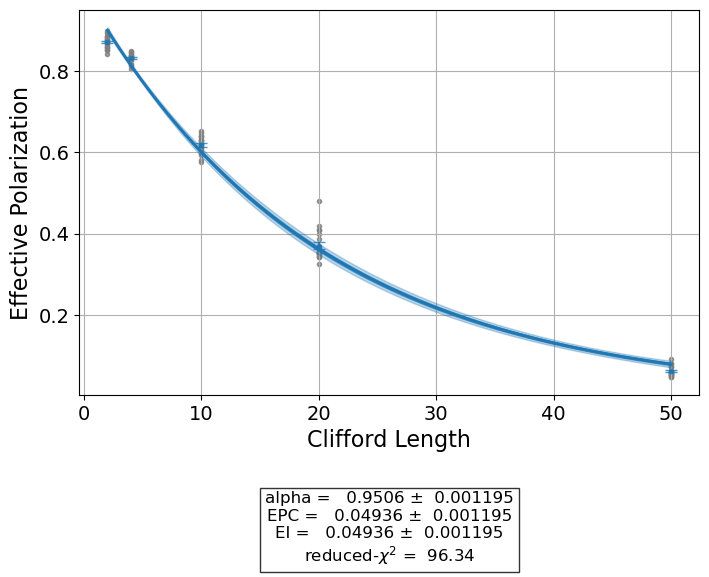

In [8]:
analysis.figure(0)

/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype

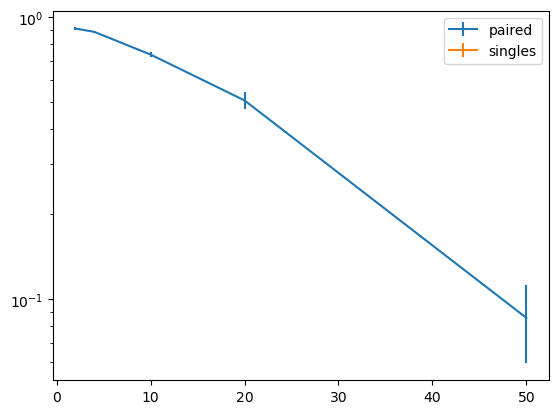

In [9]:
qa = QuantumAwesomeness(exp.backend.coupling_map)

mi = qa.mutual_info(rb_data.data())
mmi = qa.mean_mutual_info(rb_data.data(), exp._pairs)

num_lengths = len(lengths)
ys = [[[] for _ in range(num_lengths)] for _ in range(2)]
yerrs = [[], []]

for p, pairtype in enumerate(["paired", "singles"]):
    for j, m in enumerate(mmi[pairtype]):
        if m is not np.nan:
            ys[p][j % num_lengths].append(m)
    for j in range(num_lengths):
        yerrs[p].append(np.std(ys[p][j]))
        ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths, ys[0], yerr=yerrs[0], label="paired")
plt.errorbar(lengths, ys[1], yerr=yerrs[1], label="singles")
plt.yscale("log")
plt.legend()


In [15]:
for i in range(len(lengths)):                                                                                                                                  
    depth = exp._static_trans_circuits[i].depth()                                                                                                            
    print(f"length={lengths[i]:3d}: depth={depth:4d}, MI={mmi['paired'][i]:.3f}")

length=  2: depth=   9, MI=0.902
length=  4: depth=  21, MI=0.884
length= 10: depth=  41, MI=0.746
length= 20: depth=  84, MI=0.482
length= 50: depth= 199, MI=0.086


In [10]:
mmi

{'paired': [np.float64(0.9017000780454633),
  np.float64(0.8844462302487008),
  np.float64(0.7458553425323939),
  np.float64(0.4824585572508821),
  np.float64(0.08579751225407106),
  np.float64(0.9171675615028473),
  np.float64(0.8935258996155193),
  np.float64(0.738810182620449),
  np.float64(0.5036910428922174),
  np.float64(0.08610234902406709),
  np.float64(0.9132284859829692),
  np.float64(0.887537944512769),
  np.float64(0.7022527303666233),
  np.float64(0.492072481934243),
  np.float64(0.11318817771599238),
  np.float64(0.9106281800693942),
  np.float64(0.886516715794131),
  np.float64(0.7207811850237458),
  np.float64(0.521131847349583),
  np.float64(0.03865472734504939),
  np.float64(0.9056560012396428),
  np.float64(0.8841167941085286),
  np.float64(0.7595557389461093),
  np.float64(0.44975343499477904),
  np.float64(0.11588425764459069),
  np.float64(0.9015331228295127),
  np.float64(0.8863539955563564),
  np.float64(0.7194774365510698),
  np.float64(0.5063260754418132),
  n